# Project Overview
In this project we are predicting house price using input features such as otFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea with the help of simple linear regression. Here, we are first split train data in 80-20 to check model accuracy and then predict prices for test.csv 

In [14]:
#import all libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

In [3]:
#explore train data
df1=pd.read_csv('train.csv')
df1.head()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinType1_Unf,HasWoodDeck,HasOpenPorch,HasEnclosedPorch,Has3SsnPorch,HasScreenPorch,...,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice
0,1,18.144573,13.833054,7,3.991517,2003,2003,19.433175,144.117862,0.0,29.991055,422.488510,5.939034,1025.651979,0.0,8.353543,0.99344,0.000000,2,1.068837,3,0.750957,2.261968,0.000000,2003,2,548.0,0.000000,12.080309,0.000000,0.0,0.0,0.0,0.0,0,1,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,208501
1,2,20.673625,14.117918,6,6.000033,1976,1976,54.598150,181.719186,0.0,44.135415,593.888179,6.234990,665.141633,0.0,7.974693,0.00000,0.710895,2,0.000000,3,0.750957,1.996577,0.903334,1976,2,460.0,56.184223,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,181501
2,3,18.668047,14.476512,7,3.991517,2001,2002,17.768840,110.441033,0.0,56.896536,450.079716,5.994336,1040.521060,0.0,8.408064,0.99344,0.000000,2,1.068837,3,0.750957,1.996577,0.903334,2001,2,608.0,0.000000,9.901081,0.000000,0.0,0.0,0.0,0.0,0,1,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,223501
3,4,17.249651,14.106196,7,3.991517,1915,1970,54.598150,61.795315,0.0,64.808858,378.854568,6.027704,904.477422,0.0,8.358662,0.99344,0.000000,1,0.000000,3,0.750957,2.137369,0.903334,1998,3,642.0,0.000000,8.966115,16.020711,0.0,0.0,0.0,0.0,0,1,0,0,1,1,...,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,140001
4,5,21.314283,15.022008,8,3.991517,2000,2000,25.404164,136.624601,0.0,61.166379,545.309927,6.161221,1273.024863,0.0,8.669321,0.99344,0.000000,2,1.068837,4,0.750957,2.373753,0.903334,2000,3,836.0,42.245702,14.271568,0.000000,0.0,0.0,0.0,0.0,0,0,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,250001


In [6]:
#shape check
df1.shape

(1458, 380)

In [5]:
#handling missing values
df1.fillna(0)

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinType1_Unf,HasWoodDeck,HasOpenPorch,HasEnclosedPorch,Has3SsnPorch,HasScreenPorch,...,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice
0,1,18.144573,13.833054,7,3.991517,2003,2003,19.433175,144.117862,0.000000,29.991055,422.488510,5.939034,1025.651979,0.0,8.353543,0.99344,0.000000,2,1.068837,3,0.750957,2.261968,0.000000,2003,2,548.0,0.000000,12.080309,0.000000,0.0,0.0,0.0,0.000000,0,1,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,208501
1,2,20.673625,14.117918,6,6.000033,1976,1976,54.598150,181.719186,0.000000,44.135415,593.888179,6.234990,665.141633,0.0,7.974693,0.00000,0.710895,2,0.000000,3,0.750957,1.996577,0.903334,1976,2,460.0,56.184223,0.000000,0.000000,0.0,0.0,0.0,0.000000,0,0,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,181501
2,3,18.668047,14.476512,7,3.991517,2001,2002,17.768840,110.441033,0.000000,56.896536,450.079716,5.994336,1040.521060,0.0,8.408064,0.99344,0.000000,2,1.068837,3,0.750957,1.996577,0.903334,2001,2,608.0,0.000000,9.901081,0.000000,0.0,0.0,0.0,0.000000,0,1,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,223501
3,4,17.249651,14.106196,7,3.991517,1915,1970,54.598150,61.795315,0.000000,64.808858,378.854568,6.027704,904.477422,0.0,8.358662,0.99344,0.000000,1,0.000000,3,0.750957,2.137369,0.903334,1998,3,642.0,0.000000,8.966115,16.020711,0.0,0.0,0.0,0.000000,0,1,0,0,1,1,...,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,140001
4,5,21.314283,15.022008,8,3.991517,2000,2000,25.404164,136.624601,0.000000,61.166379,545.309927,6.161221,1273.024863,0.0,8.669321,0.99344,0.000000,2,1.068837,4,0.750957,2.373753,0.903334,2000,3,836.0,42.245702,14.271568,0.000000,0.0,0.0,0.0,0.000000,0,0,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,250001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1454,17.611139,13.688829,6,3.991517,1999,2000,54.598150,665.141633,0.000000,90.759786,464.212769,6.021310,828.069020,0.0,8.306538,0.00000,0.000000,2,1.068837,3,0.750957,2.137369,0.903334,1999,2,460.0,0.000000,9.643047,0.000000,0.0,0.0,0.0,0.000000,1,1,0,1,1,1,...,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,175001
1454,1455,21.472480,14.838658,6,4.679501,1978,1988,15.342608,156.123103,8.046409,68.243788,707.987030,6.607056,665.141633,0.0,8.595456,0.99344,0.000000,2,0.000000,3,0.750957,2.137369,1.688254,1978,2,500.0,62.217712,0.000000,0.000000,0.0,0.0,0.0,0.000000,0,0,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,210001
1455,1456,18.320139,13.983828,7,6.637669,1941,2006,54.598150,73.494065,0.000000,86.407866,548.233041,6.189206,1396.662961,0.0,8.748445,0.00000,0.000000,2,0.000000,4,0.750957,2.373753,1.688254,1941,1,252.0,0.000000,1

In [ ]:
#duplicated records
df1.duplicated().sum()

#observation: no duplicated records

np.int64(0)

In [11]:
#correlation
corr=df1.corr(numeric_only=True)
print(corr)

                             Id  LotFrontage  ...  SaleCondition_Partial  Saleprice
Id                     1.000000    -0.014805  ...              -0.022846  -0.021684
LotFrontage           -0.014805     1.000000  ...               0.096722   0.365421
LotArea               -0.021195     0.624252  ...               0.045232   0.394893
OverallQual           -0.030220     0.216583  ...               0.314670   0.795774
OverallCond            0.013102    -0.031857  ...              -0.148554  -0.073988
...                         ...          ...  ...                    ...        ...
SaleCondition_Alloca  -0.008982    -0.015795  ...              -0.027651  -0.015539
SaleCondition_Family   0.004932     0.011719  ...              -0.035797  -0.046499
SaleCondition_Normal   0.017203    -0.052344  ...              -0.651559  -0.154795
SaleCondition_Partial -0.022846     0.096722  ...               1.000000   0.355162
Saleprice             -0.021684     0.365421  ...               0.355162   1

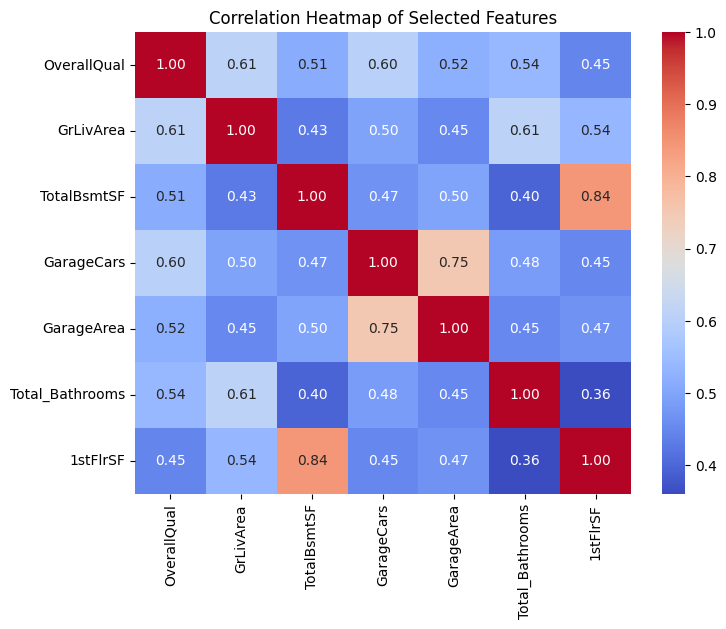

In [45]:
#selected some featurs which are highly correlated with salrsprice
selected_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'GarageArea',
    'Total_Bathrooms',
    '1stFlrSF',
    
]

plt.figure(figsize=(8,6))
sns.heatmap(df1[selected_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Selected Features")
plt.show()

In [46]:
x=df1[selected_features].drop("Saleprice",errors='ignore')
y=df1['Saleprice']

In [47]:
#perform data split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)



In [48]:
#select model
model=linear_model.LinearRegression()

In [49]:
#train model
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
#predict model outcomes
prediction=model.predict(x_test)

In [51]:
prediction_df=pd.DataFrame({
    'Actual_Price':y_test.values,
    'Predicted_Price':prediction
})
prediction_df.head()

,Actual_Price,Predicted_Price
0,190001,221876.764441
1,100001,119994.494233
2,115001,112733.232085
3,159001,179049.161697
4,315501,317651.837257


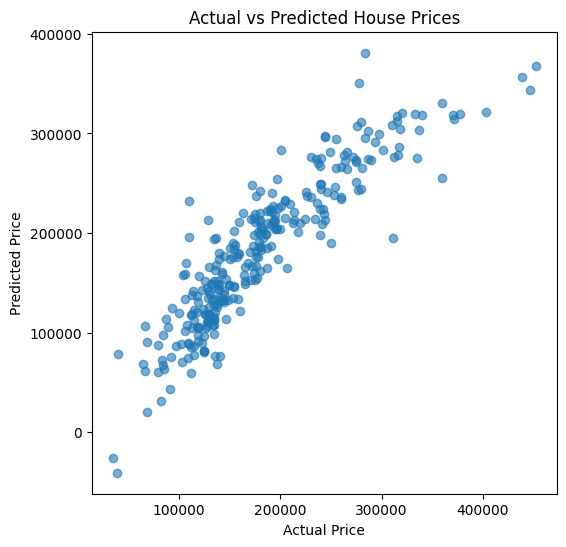

In [52]:
#graph for actual vs predicted price
plt.figure(figsize=(6,6))
plt.scatter(y_test, prediction, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [53]:
#calculate mean squared error
error=mean_squared_error(y_test,prediction)
print(error)

1107180160.0531495


In [54]:
#explore test data
df2=pd.read_csv('test.csv')
df2.head()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinType1_Unf,HasWoodDeck,HasOpenPorch,HasEnclosedPorch,Has3SsnPorch,HasScreenPorch,...,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20.673625,14.550687,5,4.679501,1961,1961,54.598150,107.505912,7.760721,42.813715,433.727206,5.974079,665.141633,0.0,7.551839,0.0,0.0,1,0.000000,2,0.750957,1.834659,0.000000,1961,1,730.0,34.371733,0.000000,0.0,0.0,19.077823,0.0,0.000000,0,0,1,1,1,0,...,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,1462,20.834996,15.023149,6,4.679501,1958,1958,14.642918,174.393644,0.000000,54.675311,621.452838,6.274101,665.141633,0.0,8.038950,0.0,0.0,1,1.068837,3,0.750957,1.996577,0.000000,1958,1,312.0,67.165906,9.105438,0.0,0.0,0.000000,0.0,10.245133,0,0,0,1,1,1,...,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1463,19.687482,14.950918,5,3.991517,1997,1998,54.598150,156.263694,0.000000,28.375987,453.511592,6.000966,836.685294,0.0,8.292787,0.0,0.0,2,1.068837,3,0.750957,1.996577,0.903334,1997,2,482.0,45.058320,8.824656,0.0,0.0,0.000000,0.0,0.000000,0,0,0,1,1,1,...,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3,1464,20.348384,14.204772,6,4.679501,1998,1998,6.157403,128.653472,0.000000,47.769042,452.653967,5.999314,808.385060,0.0,8.273443,0.0,0.0,2,1.068837,3,0.750957,2.137369,0.903334,1998,2,470.0,63.475312,9.105438,0.0,0.0,0.000000,0.0,0.000000,0,0,0,1,1,1,...,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4,1465,13.949261,12.696875,8,3.991517,1992,1992,54.598150,71.179547,0.000000,94.312871,601.311031,6.245705,665.141633,0.0,7.992275,0.0,0.0,2,0.000000,2,0.750957,1.834659,0.000000,1992,2,506.0,0.000000,14.095081,0.0,0.0,21.018870,0.0,0.000000,0,1,0,1,1,0,...,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [55]:
#shape
df2.shape

(1459, 379)

In [56]:
#handle missing values
df2.fillna(0)

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinType1_Unf,HasWoodDeck,HasOpenPorch,HasEnclosedPorch,Has3SsnPorch,HasScreenPorch,...,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20.673625,14.550687,5,4.679501,1961,1961,54.598150,107.505912,7.760721,42.813715,433.727206,5.974079,665.141633,0.0,7.551839,0.00000,0.000000,1,0.000000,2,0.750957,1.834659,0.000000,1961,1,730.000000,34.371733,0.000000,0.0,0.0,19.077823,0.0,0.000000,0,0,1,1,1,0,...,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,1462,20.834996,15.023149,6,4.679501,1958,1958,14.642918,174.393644,0.000000,54.675311,621.452838,6.274101,665.141633,0.0,8.038950,0.00000,0.000000,1,1.068837,3,0.750957,1.996577,0.000000,1958,1,312.000000,67.165906,9.105438,0.0,0.0,0.000000,0.0,10.245133,0,0,0,1,1,1,...,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1463,19.687482,14.950918,5,3.991517,1997,1998,54.598150,156.263694,0.000000,28.375987,453.511592,6.000966,836.685294,0.0,8.292787,0.00000,0.000000,2,1.068837,3,0.750957,1.996577,0.903334,1997,2,482.000000,45.058320,8.824656,0.0,0.0,0.000000,0.0,0.000000,0,0,0,1,1,1,...,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3,1464,20.348384,14.204772,6,4.679501,1998,1998,6.157403,128.653472,0.000000,47.769042,452.653967,5.999314,808.385060,0.0,8.273443,0.00000,0.000000,2,1.068837,3,0.750957,2.137369,0.903334,1998,2,470.000000,63.475312,9.105438,0.0,0.0,0.000000,0.0,0.000000,0,0,0,1,1,1,...,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4,1465,13.949261,12.696875,8,3.991517,1992,1992,54.598150,71.179547,0.000000,94.312871,601.311031,6.245705,665.141633,0.0,7.992275,0.00000,0.000000,2,0.000000,2,0.750957,1.834659,0.000000,1992,2,506.000000,0.000000,14.095081,0.0,0.0,21.018870,0.0,0.000000,0,1,0,1,1,0,...,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,8.726308,10.765922,4,5.348041,1970,1970,54.598150,665.141633,0.000000,65.236276,284.720532,5.590761,646.587946,0.0,7.795515,0.00000,0.000000,1,1.068837,3,0.750957,1.834659,0.000000,0,0,403.428793,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,1,1,1,1,1,1,...,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1455,2916,8.726308,10.723223,4,3.991517,1970,1970,54.598150,69.030589,0.000000,45.062871,284.720532,5.590761,646.587946,0.0,7.795515,0.00000,0.000000,1,1.068837,3,0.750957,1.996577,0.000000,1970,1,286.000000,0.000000,7.267260,0.0,0.0,0.000000,0.0,0.000000,0,1,0,1,1,1,...,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
1456,2917,31.755371,15.820339,5,5.348041,1960,1996,54.598150,213.123315,0.000000,0.000000,578.174364,6.211838,665.141633,0.0,7.936764,0.99344,0.000000,1,0.000000,4,0.750957,2.137369,0.903334,1960,2,576.0000

In [59]:
#predict using model
test_predict=model.predict(df2[selected_features])

In [60]:
#Creating a submition csvfile
submission = pd.DataFrame({
    'Id': df2['Id'],
    'SalePrice': test_predict
})

submission.to_csv("submission.csv", index=False)

In [61]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

# Conclusion

This project successfully developed a House Price Prediction model using Linear Regression. The dataset was preprocessed by handling missing values and selecting the most relevant features based on correlation analysis and feature engineering. The model was trained on the selected features and evaluated on a validation dataset, demonstrating strong predictive performance. Finally, the trained model was used to generate house price predictions for the unseen test dataset and create a Kaggle-compatible submission file. This project highlights the complete machine learning workflow, including data preprocessing, feature selection, model building, evaluation, and prediction using Python and Scikit-learn.